[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/08_sklearn_basics.ipynb)

# 📓 Notebook 8 (fast track) — Scikit-Learn Basics: Predicting Customer Satisfaction & Churn

> **Module:** Machine Learning · **Estimated time:** 70–90 min · **Difficulty:** Intermediate

This is where everything you have learned converges. NumPy gave us arrays, pandas gave us tables, and matplotlib/seaborn gave us charts. **Scikit-learn** gives us a beautifully uniform toolkit for training, evaluating, and using machine-learning models.

Rather than the classic Iris flowers and California housing demos, this notebook works through **two end-to-end business-AI projects** on one small, self-contained SaaS dataset:

1. **Customer satisfaction prediction** — *regression* (predict an NPS score). ← we start here
2. **Customer churn prediction** — *classification* (predict who leaves).

We do **regression first** on purpose: a linear model has just two learned numbers (a slope and an intercept), so it's the clearest place to see what `fit` and `predict` really do. Classification then reuses the *exact* same workflow — same dataset, same seven steps, just a different target and different metrics.

> 🧭 **Mental model for this notebook.** Two ideas carry everything below. (1) **Every estimator does the same two things:** `fit` = *learn numbers from data and remember them on the model*; `predict` = *apply those remembered numbers to new data.* A linear regression remembers a slope and intercept; a forest remembers trees; a scaler remembers a mean and std — but the rhythm never changes. (2) **One workflow, reused:** split → fit → predict → evaluate → iterate. Watch for these two patterns repeating: the moment you see that *churn (classification) is the same machine as satisfaction (regression) with a different dial*, scikit-learn is yours.

## 🎯 Learning objectives

1. Walk through the **scikit-learn workflow**: split → fit → predict → evaluate → iterate.
2. See exactly what `fit` and `predict` do — and **visualise the line a model learns**.
3. Train regression models and read **MAE**, **RMSE**, **R²**.
4. Use **`Pipeline`** to bundle preprocessing with the model — and avoid data leakage.
5. Diagnose **overfitting** through the **bias–variance trade-off** curve.
6. Run **cross-validation** for honest performance estimates, and tune with **`GridSearchCV`**.
7. Build and compare classifiers — and **see the decision boundary each one draws**.
8. Evaluate with the **confusion matrix**, precision/recall, F1, and the **ROC curve**.
9. **Choose a decision threshold** to match a business cost, and read **feature importances** to interpret a model.


> 🏎️ **You're on the fast track.** This is a trimmed version of the canonical [`05_machine_learning/17_sklearn_basics.ipynb`](../05_machine_learning/17_sklearn_basics.ipynb) — scikit-learn basics. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project have been removed to keep the notebook under ~90 minutes; the harder Stretch C and D are kept. Open the canonical version once you want the deeper material.

---

## 1. The ML workflow in one picture

```
                     ┌──────────────────────────────────────────┐
                     │  1. Load and explore the data            │
                     │  2. Prepare features (X) and target (y)  │
   Raw data ────────►│  3. Split into train / test              │
                     │  4. Fit a model on train (`.fit`)        │
                     │  5. Predict on test (`.predict`)         │
                     │  6. Evaluate against the truth           │
                     │  7. Iterate: try other models / features │
                     └──────────────────────────────────────────┘
```

The exact same seven-step pattern applies to **regression, classification, clustering, and beyond** — that's the *"one workflow, reused"* half of our mental model. We'll walk it once for regression (Project 1), then watch it repeat almost verbatim for classification (Project 2).

## 2. Setup

A small, fixed set of imports. Two things worth calling out:

- **`tqdm`** gives us **progress bars** — handy when we train several models in a loop and want to see how far along we are (especially live, in front of a class).
- **`RANDOM_STATE`** is fixed so every run of this notebook is identical.

In [1]:
# The Big 3 + scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm                      # progress bars

# Split, validation, tuning
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, GridSearchCV, ParameterGrid,
)
from sklearn.base import clone

# Preprocessing & pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline

RANDOM_STATE = 42

# One styling block for the whole notebook → consistent, projector-friendly charts
sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)
BLUE, RED, GREEN, ORANGE = "#4C72B0", "#C44E52", "#55A868", "#DD8452"

print("Scikit-learn ready ✅")

Scikit-learn ready ✅


## 3. The dataset — one small SaaS customer table 🧾

Both projects share **one synthetic dataset** of 600 SaaS customers. It's small on purpose: everything trains in well under a second, so you can re-run any cell live without waiting.

Every column maps to something you'd really measure in a CRM:

| column | meaning |
|---|---|
| `mrr_eur` | monthly recurring revenue (€) |
| `months_active` | tenure in months |
| `support_tickets` | tickets opened recently |
| `nps` | satisfaction score, −100…100 → **regression target** |
| `plan` | Free / Standard / Premium / Enterprise |
| `last_login_days` | days since last login |
| `churned` | left in the last period? 0/1 → **classification target** |

We build it in three small steps so each piece is easy to read.

### 3.1 Step 1 — raw customer characteristics

These are the *inputs* a CRM would record directly.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n = 600

mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
last_login_days = rng.integers(0, 90, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                             size=n, p=[0.15, 0.45, 0.30, 0.10])

print(f"{n} customers, plan mix = {pd.Series(plan).value_counts().to_dict()}")

600 customers, plan mix = {'Standard': 277, 'Premium': 185, 'Free': 79, 'Enterprise': 59}


### 3.2 Step 2 — a latent "happiness" that drives *both* targets

In real data, satisfaction (NPS) and churn aren't independent — they share a **common cause**: how happy the customer actually is. We model that single latent `happiness`, then derive **NPS** and **churn** from it. That shared cause is exactly what makes the dataset realistic.

In [3]:
plan_adj = np.array([{"Free": -0.45, "Standard": 0.0,
                      "Premium": 0.15, "Enterprise": 0.35}[p] for p in plan])

happiness = (
    -0.40 * (support_tickets - 2.5) / 2.0      # many tickets → unhappy
    -0.80 * (last_login_days - 45) / 30.0      # absent users → unhappy
    +0.35 * (np.log1p(mrr_eur) - 6.5) / 1.5    # higher MRR → mildly happier
    +0.30 * (months_active - 30) / 20.0        # tenure helps
    + plan_adj
    + rng.normal(0, 0.30, n)                   # noise
)

# NPS: happiness mapped onto a -100..100 scale, plus measurement noise
nps = (40 + 35 * happiness + rng.normal(0, 8, n)).clip(-100, 100)

# Churn: a logistic function of happiness → ~30% churn overall
churn_prob = 1 / (1 + np.exp(-(-1.6 - 2.5 * happiness)))
churned    = (rng.random(n) < churn_prob).astype(int)

print(f"NPS range  : {nps.min():.0f} … {nps.max():.0f}")
print(f"Churn rate : {churned.mean():.1%}")

NPS range  : -48 … 100
Churn rate : 26.8%


### 3.3 Step 3 — assemble the table

In [4]:
churn_df = pd.DataFrame({
    "mrr_eur":         mrr_eur.round(2),
    "months_active":   months_active,
    "support_tickets": support_tickets,
    "nps":             nps.round(1),
    "plan":            plan,
    "last_login_days": last_login_days,
    "churned":         churned,
})

print(f"Shape: {churn_df.shape}")
churn_df.head()

Shape: (600, 7)


,mrr_eur,months_active,support_tickets,nps,plan,last_login_days,churned
0,823.28,15,1,8.6,Free,74,1
1,321.18,25,4,5.1,Standard,58,0
2,1124.75,5,3,80.1,Standard,2,0
3,1284.85,47,3,17.3,Standard,70,1
4,169.74,39,2,21.6,Standard,54,0


> 💡 **A note on synthetic data.** We engineered a plausible signal so the demo runs without a download. The patterns the models learn — login recency matters, NPS matters, free plans churn more — are *qualitatively* the same ones you'd find in real SaaS data.

# 📈 Project 1 — Regression: predicting customer satisfaction

**Goal:** predict a customer's **NPS score** (a number from −100 to 100) from the other columns.

Regression = *predict a number*. We start here because the simplest regressor — a straight line — has only two learned numbers, which makes it the perfect place to see what `fit` and `predict` actually do.

## 4. Features, target, and the train/test split

### 4.1 Pull out X and y

`y` is what we want to predict (`nps`). `X` is everything we're allowed to use to predict it. We drop `churned` too — it's a *downstream* outcome, not something we'd know at prediction time.

In [5]:
X_reg = churn_df.drop(columns=["nps", "churned"])
y_reg = churn_df["nps"].values

print("Features:", list(X_reg.columns))
print("Target  : nps   (shape", y_reg.shape, ")")

Features: ['mrr_eur', 'months_active', 'support_tickets', 'plan', 'last_login_days']
Target  : nps   (shape (600,) )


### 4.2 Hold out a test set

We hold out **20%** of the rows as a test set we won't touch until the very end. The model is graded on data it has **never seen** — the only honest measure of how it will behave on next month's customers.

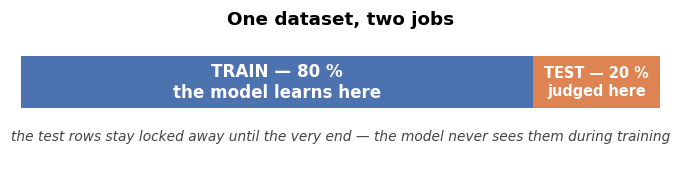

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE,
)

print(f"Train: {X_tr.shape[0]} customers")
print(f"Test : {X_te.shape[0]} customers")

Train: 480 customers
Test : 120 customers


### 4.3 The scikit-learn API contract

Every estimator follows the same four-line shape — that's the genius of scikit-learn:

```python
model = SomeModel(hyperparam=value)   # 1. choose
model.fit(X_train, y_train)           # 2. learn from training data
y_pred = model.predict(X_test)        # 3. apply to new data
score  = model.score(X_test, y_test)  # 4. grade
```

This uniformity means **swapping a linear regression for a random forest is a one-line change.** Before we use it, let's open the box and see what `fit` and `predict` really do.

### 🔬 What actually happens inside `fit` and `predict`

The contract hides a tiny, mechanical truth that makes every estimator click: **`fit` learns numbers and *remembers* them on the model; `predict` just *applies* those remembered numbers.** That's the whole estimator lifecycle.

Scikit-learn marks "this was learned during `fit`" with a **trailing-underscore** name. A fitted `LinearRegression` stores exactly two things:

- `model.coef_` — one weight per feature
- `model.intercept_` — the bias term

```text
            ┌──────────── fit(X, y) ────────────┐
   X, y ───►│  learns weights & bias from data  │
            └───────────────────────────────────┘
                          │ STORES on the model
                          ▼
                ┌───────────────────────┐
                │  model.coef_          │   ← the remembered numbers
                │  model.intercept_     │
                └───────────────────────┘
                          │ predict(X) APPLIES them
                          ▼
                 ŷ = X @ coef_ + intercept_
```

`fit` = **learn-and-remember**. `predict` = **apply the remembered numbers**. Nothing more. Let's prove it on a tiny, fully offline example.

First, fit a `LinearRegression` on **four inline points** and look at what it remembered:

In [7]:
from sklearn.linear_model import LinearRegression

# Tiny inline dataset: 2 features, 4 samples (no files, no downloads)
X_demo = np.array([[1.0, 0.0],
                   [2.0, 1.0],
                   [3.0, 0.0],
                   [4.0, 1.0]])
y_demo = np.array([3.0, 6.0, 7.0, 10.0])

demo = LinearRegression().fit(X_demo, y_demo)   # ← LEARN

print("coef_     :", demo.coef_.round(4))       # one weight per feature
print("intercept_:", round(float(demo.intercept_), 4))

coef_     : [2. 1.]
intercept_: 1.0


Now reproduce **one prediction by hand** and `assert` it matches `.predict()` — proving `predict` is *literally* `X @ coef_ + intercept_`:

In [8]:
x_new = np.array([5.0, 1.0])

by_hand    = x_new @ demo.coef_ + demo.intercept_     # ŷ = x·coef_ + intercept_
by_sklearn = demo.predict(x_new.reshape(1, -1))[0]

print("by hand   :", round(float(by_hand), 6))
print("by sklearn:", round(float(by_sklearn), 6))
assert np.isclose(by_hand, by_sklearn)
print("✅ x @ coef_ + intercept_  ==  model.predict(x)")

by hand   : 12.0
by sklearn: 12.0
✅ x @ coef_ + intercept_  ==  model.predict(x)


> 🧠 **Mental model.** `fit = learn-and-remember; predict = apply the remembered numbers.` Every estimator follows this — a `RandomForestRegressor` remembers trees in `estimators_`, a `StandardScaler` remembers `mean_`/`scale_`. Calling `predict`/`transform` *before* `fit` raises `NotFittedError` precisely because the remembered numbers don't exist yet.

> ⚠️ **`fit` resets.** Calling `fit` again throws away the old numbers and relearns from scratch — it does not accumulate. That's also why we `fit` on **train** only and merely `predict` on **test**: the test data must never get a vote in what the model remembers.

### 📐 Seeing it: the straight line `fit` actually drew

`coef_` and `intercept_` aren't abstract — together they **are a line**. Let's make it visible. We fit a *one-feature* linear regression — **NPS as a function of days since last login** — and draw exactly what the model remembered. Each grey segment is one customer's **residual** (the gap between the line and reality). Least-squares picked the one slope and intercept that make the **sum of those squared gaps** as small as possible — that is the entire "learning".


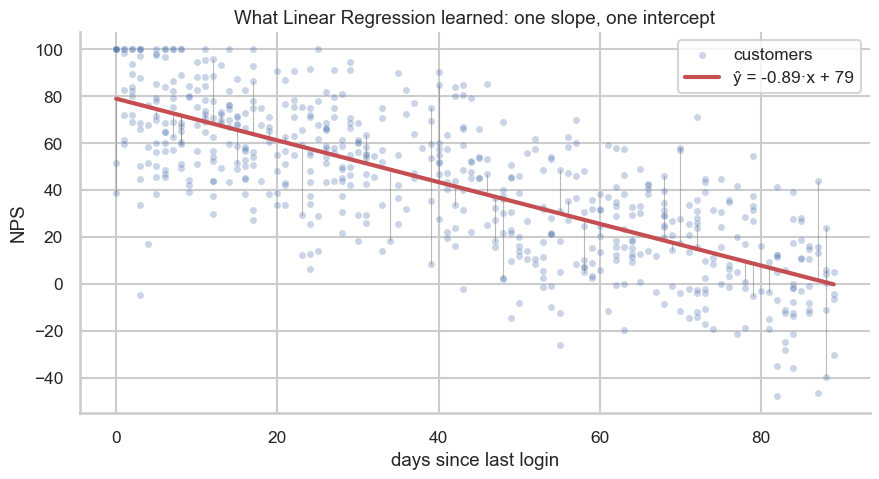

slope (coef_)  = -0.889  → each extra idle day moves predicted NPS by -0.89
intercept_     = 78.9   → predicted NPS for a customer who just logged in


In [9]:
# One feature → we can literally see the line the model learned
feat = "last_login_days"
xs = churn_df[[feat]].values
ys = churn_df["nps"].values

line = LinearRegression().fit(xs, ys)
grid = np.linspace(xs.min(), xs.max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(xs, ys, alpha=0.30, s=26, color=BLUE,
           edgecolor="white", linewidth=0.4, label="customers")

# residuals as faint drop-lines (sample 40 so the picture stays readable)
samp = np.random.default_rng(0).choice(len(xs), 40, replace=False)
for j in samp:
    ax.plot([xs[j, 0], xs[j, 0]],
            [ys[j], line.predict(xs[j].reshape(1, -1))[0]],
            color="grey", lw=0.8, alpha=0.55)

ax.plot(grid, line.predict(grid), color=RED, lw=3,
        label=f"ŷ = {line.coef_[0]:.2f}·x + {line.intercept_:.0f}")
ax.set(xlabel="days since last login", ylabel="NPS",
       title="What Linear Regression learned: one slope, one intercept")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

print(f"slope (coef_)  = {line.coef_[0]:+.3f}  → each extra idle day moves predicted NPS by {line.coef_[0]:+.2f}")
print(f"intercept_     = {line.intercept_:.1f}   → predicted NPS for a customer who just logged in")


> The slope is clearly **negative** — idle customers are unhappy customers, and that single number captures it. Adding the other features (the full pipeline above) doesn't change the idea; it just gives the line **more dimensions to tilt in**. A picture you can't draw past 3-D, but the maths is identical.


## 5. A preprocessing pipeline

Our features mix **numeric** and **categorical** types, so before any model sees them we need to:

- **Standardise** numeric columns (mean 0, std 1) — so a feature measured in thousands (MRR) doesn't dwarf one measured in tens (tickets).
- **One-hot encode** the `plan` column — turn one text column into 0/1 indicator columns.

We wrap both in a `ColumnTransformer` and, crucially, do it **inside a `Pipeline`** so the preprocessing is fit on the *training data only*, then re-applied identically to the test data. That single discipline avoids one of the most damaging beginner mistakes: **data leakage**.

In [10]:
reg_numeric = ["mrr_eur", "months_active", "support_tickets", "last_login_days"]
reg_cat     = ["plan"]

reg_prep = ColumnTransformer([
    ("num", StandardScaler(),                       reg_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_cat),
])

# Peek at the output shape (fit on TRAIN only)
X_tr_t = reg_prep.fit_transform(X_tr)
print(f"Transformed shape: {X_tr_t.shape}")
print("Columns:", reg_prep.get_feature_names_out().tolist())

Transformed shape: (480, 8)
Columns: ['num__mrr_eur', 'num__months_active', 'num__support_tickets', 'num__last_login_days', 'cat__plan_Enterprise', 'cat__plan_Free', 'cat__plan_Premium', 'cat__plan_Standard']


## 6. A first model — Linear Regression

One `Pipeline`: preprocessing → model. We `fit`, `predict`, and score with three regression metrics.

In [11]:
pipe_lin = Pipeline([("prep", reg_prep), ("model", LinearRegression())])
pipe_lin.fit(X_tr, y_tr)
yhat_lin = pipe_lin.predict(X_te)
print("Linear Regression trained ✅")

Linear Regression trained ✅


> 🔎 **See the Pipeline itself.** A `Pipeline` isn't a black box — scikit-learn can draw it. The diagram below shows the two steps in order: the `ColumnTransformer` (which scales the numeric columns and one-hot-encodes `plan`) feeding the model. Click any box to expand its parameters. This is the *exact* object that gets `fit`, cross-validated, and tuned — preprocessing and model travelling together as one estimator.


In [12]:
from sklearn import set_config
set_config(display="diagram")     # render estimators as interactive HTML diagrams

pipe_lin                          # displaying a Pipeline now draws its structure


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }

scores_lin = regression_report(y_te, yhat_lin)
print(f"  MAE  = {scores_lin['MAE']:.2f}  NPS points")
print(f"  RMSE = {scores_lin['RMSE']:.2f}  NPS points")
print(f"  R²   = {scores_lin['R2']:.3f}")

  MAE  = 10.65  NPS points
  RMSE = 13.41  NPS points
  R²   = 0.809


**How to read regression metrics:**

- **MAE** (mean absolute error) — the typical error in target units. Easy to say out loud: *"on average we're off by X NPS points."*
- **RMSE** (root mean squared error) — like MAE but **penalises large errors more**. Use it when the occasional huge miss is especially bad.
- **R²** (coefficient of determination) — fraction of the variance the model explains, in (−∞, 1]. `1.0` = perfect; `0` = no better than always predicting the mean; negative = worse than the mean.

---

### ✋ Quick exercise (~2 min) — Report the model's accuracy

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your linear model's test predictions are in `yhat_lin` and the truth is `y_te`. Call the metric functions **directly** to print the model's R² and MAE, then say it out loud: *"on average we're off by … NPS points."*

```python
# mean_absolute_error and r2_score were imported just above.
```

In [ ]:
# ✍️ Your turn 👇
mae = ...   # mean absolute error of yhat_lin vs y_te
r2  = ...   # R² of yhat_lin vs y_te


<details>
<summary>✅ <b>Solution</b></summary>

```python
mae = mean_absolute_error(y_te, yhat_lin)
r2  = r2_score(y_te, yhat_lin)
print(f"R² = {r2:.3f}  |  on average we're off by {mae:.1f} NPS points")
```

Both metric functions take `(y_true, y_pred)` in that order. R² is the fraction of variance explained; MAE is the typical error in the target's own units (NPS points).
</details>

## 7. Compare several regressors — with a progress bar

Same `Pipeline` skeleton, only the final model changes. We loop over four regressors and wrap the loop in **`tqdm`** so we get a live progress bar — exactly what you want when a comparison takes a few seconds in front of a class.

In [14]:
from sklearn.tree     import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble  import RandomForestRegressor

regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "k-NN (k=7)":        KNeighborsRegressor(n_neighbors=7),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               random_state=RANDOM_STATE, n_jobs=-1),
}

reg_results = {}
for name, model in tqdm(regressors.items(), desc="Training regressors"):
    pipe = Pipeline([("prep", reg_prep), ("model", model)])
    pipe.fit(X_tr, y_tr)
    reg_results[name] = (pipe, regression_report(y_te, pipe.predict(X_te)))

reg_table = (pd.DataFrame({n: s for n, (_, s) in reg_results.items()}).T
               .sort_values("R2", ascending=False).round(3))
reg_table

Training regressors:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,RMSE,R2
Linear Regression,10.653,13.407,0.809
Random Forest,12.113,15.433,0.747
k-NN (k=7),12.730,16.603,0.707
Decision Tree,15.404,19.722,0.586


### 7.1 The comparison as a chart

A table is precise; a bar chart is instant. Higher **R²** is better.

> On this small dataset a plain linear model is already competitive — a useful reminder that *fancier ≠ better*. For the rest of the workflow (cross-validation, tuning, feature importance) we'll work with the **Random Forest**, since it's the one with interesting knobs to turn and an importance ranking to read.

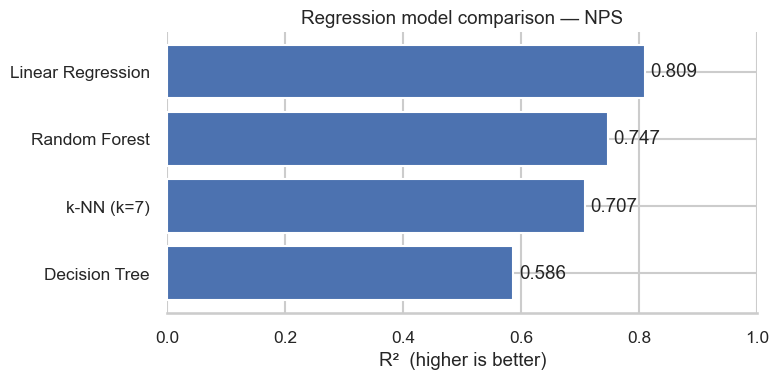

Best regressor on the test set: Linear Regression


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
order = reg_table.sort_values("R2")
bars = ax.barh(order.index, order["R2"], color=BLUE)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(xlabel="R²  (higher is better)", title="Regression model comparison — NPS")
ax.set_xlim(0, 1)
sns.despine(left=True)
plt.tight_layout()
plt.show()

best_reg_name = reg_table.index[0]
pipe_rf = reg_results["Random Forest"][0]        # the RF pipeline — tuned & interpreted below
print(f"Best regressor on the test set: {best_reg_name}")

## 8. Predicted vs actual — the key diagnostic plot

This is the single most useful regression debugging chart: plot **predicted** values against **true** ones. A perfect model lies on the dashed diagonal; the spread around it *is* the error.

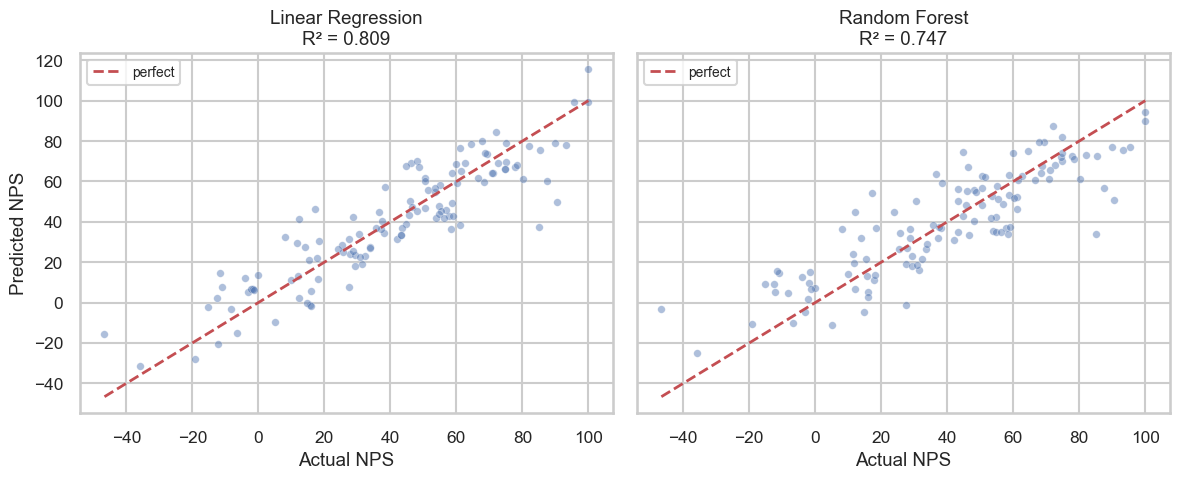

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, (yhat, name) in zip(axes, [(yhat_lin, "Linear Regression"),
                                   (pipe_rf.predict(X_te), "Random Forest")]):
    ax.scatter(y_te, yhat, alpha=0.45, s=30, color=BLUE, edgecolor="white", linewidth=0.4)
    lo, hi = y_te.min(), y_te.max()
    ax.plot([lo, hi], [lo, hi], "--", color=RED, lw=2, label="perfect")
    r2 = r2_score(y_te, yhat)
    ax.set(xlabel="Actual NPS", title=f"{name}\nR² = {r2:.3f}")
    ax.legend(loc="upper left", fontsize=10)
axes[0].set_ylabel("Predicted NPS")
plt.tight_layout()
plt.show()

A tight cloud along the diagonal means good predictions. Systematic shapes are diagnostic: a **curve** means you're missing a non-linear effect, a **vertical offset** means bias, a **fan** means the error grows with the value. That's *far* more actionable than a single R² number.

## 9. Overfitting — the bias–variance trade-off in one picture

Every test score so far came from **one** split, and we quietly assumed *more complex model → better*. Both assumptions can betray you. Here is arguably the most important diagnostic in all of machine learning.

We take a single `DecisionTreeRegressor` and grow it from a shallow stump (`max_depth=1`) to a deep tree (`max_depth=20`), recording two scores at every depth:

- **Training R²** — how well it fits the data it *learned from*.
- **Test R²** — how well it does on data it has *never seen*.

Watch them diverge.


### 🔮 Predict the output

A model's score on the data it **trained on** is not its score on **unseen** data. This tiny self-contained example fits an over-flexible decision tree. Predict which R² is higher (and roughly how they compare) **before** running.

```python
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(0)
X = rng.uniform(0, 10, size=(60, 1))
y = np.sin(X).ravel() + rng.normal(0, 0.3, size=60)   # signal + noise

Xtr, Xte = X[:40], X[40:]
ytr, yte = y[:40], y[40:]

tree = DecisionTreeRegressor(max_depth=None, random_state=0).fit(Xtr, ytr)
print("train R^2:", round(tree.score(Xtr, ytr), 3))
print("test  R^2:", round(tree.score(Xte, yte), 3))
```


In [17]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(0)
X = rng.uniform(0, 10, size=(60, 1))
y = np.sin(X).ravel() + rng.normal(0, 0.3, size=60)   # signal + noise

Xtr, Xte = X[:40], X[40:]
ytr, yte = y[:40], y[40:]

tree = DecisionTreeRegressor(max_depth=None, random_state=0).fit(Xtr, ytr)
print("train R^2:", round(tree.score(Xtr, ytr), 3))
print("test  R^2:", round(tree.score(Xte, yte), 3))


train R^2: 1.0
test  R^2: 0.35


<details>
<summary>💡 <b>Answer</b></summary>

**Train R² = `1.0`; test R² is far lower (around `0.3`).**

A full-depth tree can grow a leaf for *every* training point, so it memorises the training set perfectly — train R² is a flawless `1.0`. But it memorised the **noise** too, so on the held-out test set it generalises poorly. That gap *is* overfitting. The lesson driving this whole section: **never judge a model by its training score** — only the test (or cross-validation) score tells you how it will behave on new data.
</details>


Growing the tree:   0%|          | 0/20 [00:00<?, ?it/s]

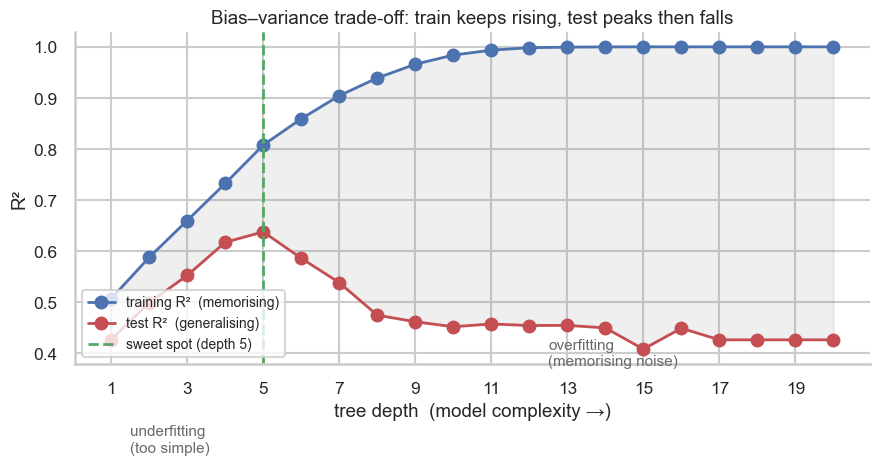

Best depth on the test set: 5  (train R² = 0.808, test R² = 0.638)
Deepest tree (depth 20):    train R² = 1.000, test R² = 0.427  ← the gap is the overfitting


In [18]:
depths = range(1, 21)
train_r2, test_r2 = [], []
for d in tqdm(depths, desc="Growing the tree"):
    m = Pipeline([("prep", reg_prep),
                  ("model", DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    m.fit(X_tr, y_tr)
    train_r2.append(r2_score(y_tr, m.predict(X_tr)))
    test_r2.append(r2_score(y_te, m.predict(X_te)))

best_d = list(depths)[int(np.argmax(test_r2))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_r2, "o-", color=BLUE, lw=2, label="training R²  (memorising)")
ax.plot(depths, test_r2,  "o-", color=RED,  lw=2, label="test R²  (generalising)")
ax.axvline(best_d, color=GREEN, ls="--", lw=2, label=f"sweet spot (depth {best_d})")
ax.fill_between(depths, test_r2, train_r2, color="grey", alpha=0.12)
ax.annotate("underfitting\n(too simple)", xy=(1, test_r2[0]), xytext=(1.5, test_r2[0] - 0.22),
            fontsize=11, color="dimgrey")
ax.annotate("overfitting\n(memorising noise)", xy=(19, test_r2[-1]), xytext=(12.5, test_r2[-1] - 0.05),
            fontsize=11, color="dimgrey")
ax.set(xlabel="tree depth  (model complexity →)", ylabel="R²",
       title="Bias–variance trade-off: train keeps rising, test peaks then falls",
       xticks=list(depths)[::2])
ax.legend(loc="lower left", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Best depth on the test set: {best_d}  "
      f"(train R² = {train_r2[best_d-1]:.3f}, test R² = {test_r2[best_d-1]:.3f})")
print(f"Deepest tree (depth 20):    train R² = {train_r2[-1]:.3f}, test R² = {test_r2[-1]:.3f}  ← the gap is the overfitting")


**Reading the most important chart in ML.**

- **Left edge — underfitting (high *bias*).** A depth-1 tree is too simple to capture the signal, so *both* scores are low. The model is wrong in a systematic, structural way.
- **Right edge — overfitting (high *variance*).** As depth grows, training R² marches toward 1.0 — the tree is memorising individual customers, noise and all. But test R² **peaks and then declines**: memorised quirks don't generalise to next month's customers.
- **The shaded gap between the two lines *is* the overfitting.** A thin band means the model generalises; a widening chasm means it memorised.

The sweet spot — the depth that maximises *test* R² — is exactly what hyperparameter tuning (§11) automates. And because a single split's peak is itself a bit lucky, we locate it honestly with **cross-validation**, which is next.


### Would more data help? — the learning curve

The curve above varied *model complexity*. Its twin varies the **amount of training data**: `learning_curve` retrains the model on 10%, 20%, … 100% of the training set and tracks the cross-validated score at each size. It answers the question every team eventually asks — *"should we go collect more data, or have we plateaued?"*


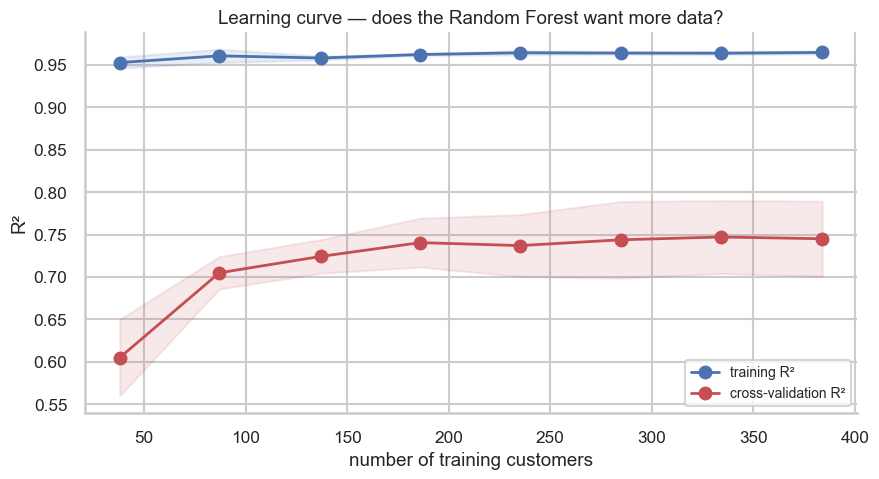

CV R² at  38 customers: 0.605
CV R² at 384 customers: 0.745  (gained +0.140 from 346 more rows)


In [19]:
from sklearn.model_selection import learning_curve

sizes, train_sc, val_sc = learning_curve(
    clone(pipe_rf), X_tr, y_tr,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring="r2", n_jobs=-1,
    random_state=RANDOM_STATE,
)
train_mean, train_std = train_sc.mean(1), train_sc.std(1)
val_mean,   val_std   = val_sc.mean(1),   val_sc.std(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, train_mean, "o-", color=BLUE, lw=2, label="training R²")
ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, color=BLUE, alpha=0.12)
ax.plot(sizes, val_mean, "o-", color=RED, lw=2, label="cross-validation R²")
ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, color=RED, alpha=0.12)
ax.set(xlabel="number of training customers", ylabel="R²",
       title="Learning curve — does the Random Forest want more data?")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"CV R² at  {int(sizes[0])} customers: {val_mean[0]:.3f}")
print(f"CV R² at {int(sizes[-1])} customers: {val_mean[-1]:.3f}  "
      f"(gained {val_mean[-1] - val_mean[0]:+.3f} from {int(sizes[-1] - sizes[0])} more rows)")


**Reading the learning curve.**

- The **validation curve still rising** at the right edge → more data would likely *keep* helping. A **flat** validation curve → you've plateaued; spend your effort on features or a different model instead, not on collecting rows.
- A **large persistent gap** between training and validation (training near-perfect, validation well below) is the data-hungry signature of a high-variance model — more data narrows that gap.
- Together with §9, these are the two diagnostics that tell you *which lever to pull*: complexity (§9) or data (here).


## 10. Cross-validation — a more honest score

The R² above came from **one** train/test split — and that number is partly luck. Re-shuffle with a different `random_state` and you'd get a slightly different score, because *which* customers happen to land in the test set matters.

**k-fold cross-validation** removes that luck:

1. Split the **training data** into `k` equal parts (*folds*; here `k = 5`).
2. Train on `k−1` folds, score on the held-out fold.
3. Rotate until every fold has been the validation fold exactly once.
4. Report the **mean** of the `k` scores and their **standard deviation** (how stable the score is).

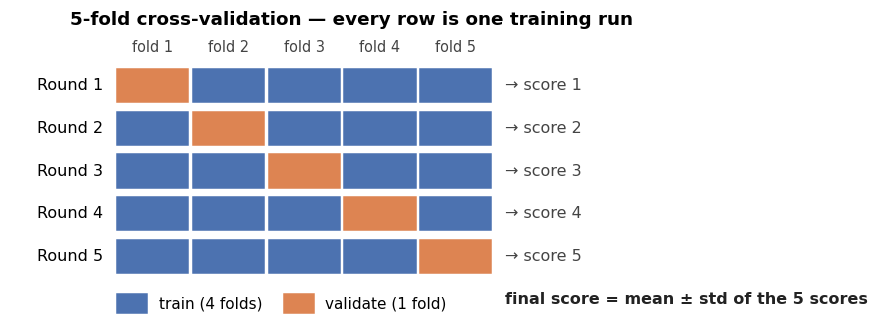

Below we run the folds **by hand** so you can see the mechanism — and so the progress bar shows one tick per fold.

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_scores = []

for tr_idx, va_idx in tqdm(kf.split(X_tr), total=5, desc="CV folds"):
    fold_pipe = clone(pipe_rf)                                  # fresh, unfitted copy
    fold_pipe.fit(X_tr.iloc[tr_idx], y_tr[tr_idx])             # train on k-1 folds
    fold_scores.append(r2_score(y_tr[va_idx],                  # score on held-out fold
                                fold_pipe.predict(X_tr.iloc[va_idx])))

fold_scores = np.array(fold_scores)
print(f"Per-fold R² : {fold_scores.round(3)}")
print(f"Mean ± std  : {fold_scores.mean():.3f} ± {fold_scores.std():.3f}")

CV folds:   0%|          | 0/5 [00:00<?, ?it/s]

Per-fold R² : [0.777 0.764 0.773 0.693 0.736]
Mean ± std  : 0.749 ± 0.031


The one-liner that does **all of the above** — and re-fits the preprocessing inside each fold so nothing leaks — is `cross_val_score`. We pass the whole **`Pipeline`**, not the bare model:

In [21]:
cv_scores = cross_val_score(pipe_rf, X_tr, y_tr, cv=5, scoring="r2", n_jobs=-1)
print(f"cross_val_score : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

cross_val_score : 0.745 ± 0.044


**How to read it.** The mean is your honest estimate; the std is its error bar. ±0.02 means *"this score is solid"*; ±0.15 means *"don't quote the second digit on a slide."* If one fold scores far below the others, some segment of your data is harder — worth investigating before shipping.

Three rules that keep cross-validation honest:

1. **Cross-validate on the *training* data only.** The test set stays in the vault for one final check.
2. **Cross-validate the whole `Pipeline`, not the bare model** — so preprocessing is re-fit *inside* each fold and a validation fold never leaks into scaling/encoding.
3. **For classification, keep the class balance per fold** — scikit-learn does this automatically (stratified folds) for classifiers.

---

### ✋ Quick exercise (~2 min) — Cross-validate the linear model

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You just cross-validated the Random Forest pipeline. Now get an **honest** R² for the simple `pipe_lin` (Linear Regression) using `cross_val_score` with 5 folds on the **training** data, and print its mean ± std.

```python
# Use the one-liner: cross_val_score(estimator, X_tr, y_tr, cv=5, scoring="r2")
```

In [ ]:
# ✍️ Your turn 👇
lin_cv = ...   # cross_val_score on pipe_lin


<details>
<summary>✅ <b>Solution</b></summary>

```python
lin_cv = cross_val_score(pipe_lin, X_tr, y_tr, cv=5, scoring="r2", n_jobs=-1)
print(f"Linear Regression CV R²: {lin_cv.mean():.3f} ± {lin_cv.std():.3f}")
```

Cross-validating on the *training* set only (the test set stays in the vault) gives a more trustworthy estimate than a single split — and lets you fairly compare the linear baseline against the Random Forest.
</details>

## 11. Hyperparameter tuning with `GridSearchCV`

Every model has two kinds of knobs:

| | Who sets it | When | Examples |
|---|---|---|---|
| **Parameters** | the algorithm — *learned* by `.fit()` | during training | regression coefficients, a tree's split thresholds |
| **Hyperparameters** | *you* — chosen before training | before training | `n_estimators`, `max_depth`, `k` in k-NN |

*"Is 300 trees better than 100? Should the trees be deeper?"* You could answer with a hand-written loop: for every combination, cross-validate, remember the best. Let's do exactly that — with a progress bar — so the tool feels demystified before we use it.

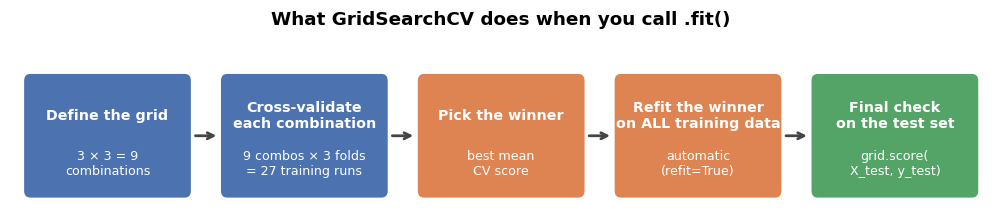

In [22]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth":    [4, 8, 16],
}

# The grid by hand: every combination, 3-fold CV, remember the mean score.
# (`model__max_depth` → the "model" step's "max_depth" hyperparameter.)
records = []
for params in tqdm(list(ParameterGrid(param_grid)), desc="Grid search"):
    cand = clone(pipe_rf).set_params(**params)
    cv = cross_val_score(cand, X_tr, y_tr, cv=3, scoring="r2", n_jobs=-1)
    records.append({**params, "mean_r2": cv.mean()})

grid_df = pd.DataFrame(records)
print(f"{len(grid_df)} combinations × 3 folds = {len(grid_df) * 3} training runs")

Grid search:   0%|          | 0/9 [00:00<?, ?it/s]

9 combinations × 3 folds = 27 training runs


### 11.1 The result as a heatmap

`n_estimators` runs across the columns, `max_depth` down the rows. The brightest cell is the best combination.

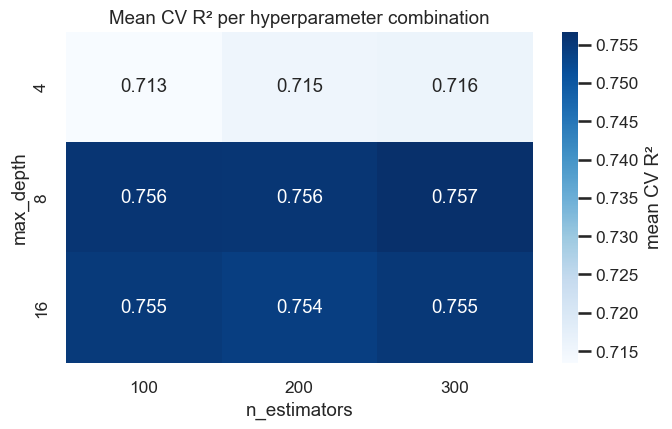

In [23]:
scores = grid_df.pivot(index="model__max_depth",
                       columns="model__n_estimators", values="mean_r2")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(scores, annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "mean CV R²"}, ax=ax)
ax.set(title="Mean CV R² per hyperparameter combination",
       xlabel="n_estimators", ylabel="max_depth")
plt.tight_layout()
plt.show()

### 11.2 The productized one-liner

`GridSearchCV` **is** that loop, packaged — and with `refit=True` (the default) it re-fits the winning model on *all* the training data, so afterwards `grid` *is* the best model: you can call `.predict()` / `.score()` on it directly.

In [24]:
grid = GridSearchCV(pipe_rf, param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_tr, y_tr)

print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.3f}   (seen during the search)")
print(f"Test  R²    : {grid.score(X_te, y_te):.3f}   (the vault — seen once, now)")

Best params : {'model__max_depth': 8, 'model__n_estimators': 300}
Best CV R²  : 0.757   (seen during the search)
Test  R²    : 0.748   (the vault — seen once, now)


**Reading the result.**

- Scores barely change **along a row** → `n_estimators` stops mattering after ~100–200 trees (more trees cost time, not accuracy).
- Scores change **down a column** → `max_depth` is the knob that matters here.
- If the best cell sits **on the edge** of the grid, the grid is too small — widen the range and search again.
- **Best CV R²** vs **Test R²** should be close. If CV looks great but test is clearly worse, the search overfit the validation folds — use fewer combinations, more folds, or more data.

> 💡 **When the grid explodes** (4 knobs × 5 values = 625 combos), switch to `RandomizedSearchCV(..., n_iter=20)` — it samples combinations instead of trying all of them, and usually finds a near-best setting at a fraction of the cost.

## 12. Feature importance — what is the model relying on?

A trained Random Forest can report which features it actually used. This is the cheapest interpretability tool you have — and a quiet **leakage detector**.

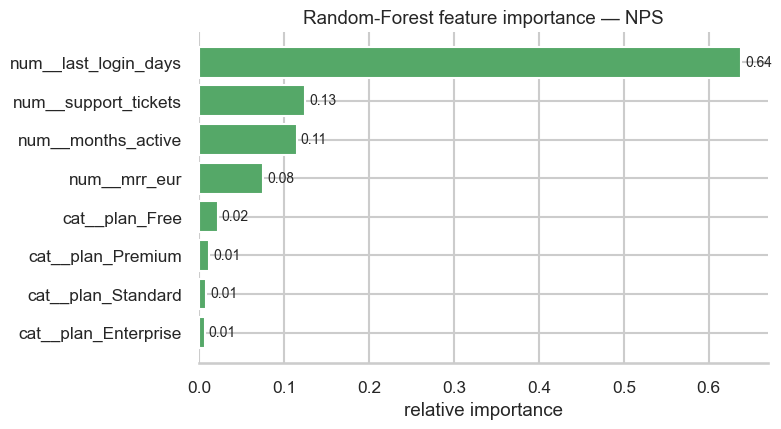

In [25]:
rf_model = pipe_rf.named_steps["model"]
reg_importance = (pd.Series(rf_model.feature_importances_,
                            index=pipe_rf.named_steps["prep"].get_feature_names_out())
                    .sort_values())

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(reg_importance.index, reg_importance.values, color=GREEN)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set(title="Random-Forest feature importance — NPS", xlabel="relative importance")
sns.despine(left=True)
plt.tight_layout()
plt.show()

**Reading the chart.** The top features should match business intuition (support tickets, login recency, plan). If a feature you *didn't* expect tops the list, investigate — that's often where leakage hides.

That's the full regression workflow: split → preprocess → fit → evaluate → cross-validate → tune → interpret. **Classification reuses every one of these steps.**

### ⚠️ A caveat — and a more trustworthy importance

The chart above uses the Random Forest's built-in `feature_importances_`, which is **impurity-based**: it measures how often each feature was used to split, on the *training* data. That metric has a well-known bias — it **inflates high-cardinality and continuous features** (like `mrr_eur`) simply because they offer more places to split, even when they carry little real signal.

A more honest alternative is **permutation importance**: take the *fitted* model, shuffle one feature column in the **test** set, and measure how much the score drops. A feature the model truly relies on, when scrambled, hurts performance; a feature it ignores does nothing. It's model-agnostic, computed on held-out data, and works on the *original* columns (not the one-hot-expanded ones).


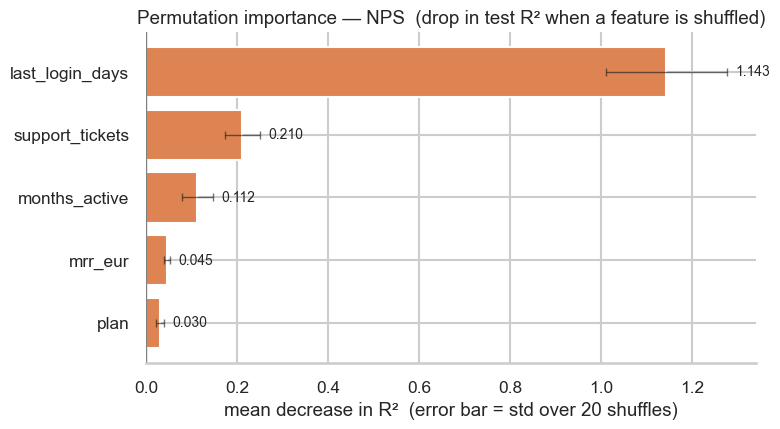

In [26]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    pipe_rf, X_te, y_te, scoring="r2",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_imp = pd.Series(perm.importances_mean, index=X_te.columns).sort_values()
perm_err = pd.Series(perm.importances_std,  index=X_te.columns).reindex(perm_imp.index)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(perm_imp.index, perm_imp.values, xerr=perm_err.values,
               color=ORANGE, capsize=3, error_kw={"lw": 1, "alpha": 0.6})
ax.bar_label(bars, fmt="%.3f", padding=6, fontsize=10)
ax.set(title="Permutation importance — NPS  (drop in test R² when a feature is shuffled)",
       xlabel="mean decrease in R²  (error bar = std over 20 shuffles)")
ax.axvline(0, color="grey", lw=1)
sns.despine(left=True)
plt.tight_layout()
plt.show()


**Reading it — and comparing the two rankings.** The ordering is broadly the same as the impurity chart (login recency and tickets matter most), which is reassuring. But note the **error bars**: a feature whose importance bar overlaps zero isn't reliably contributing. When the two methods *disagree* — especially when impurity ranks a continuous feature high but permutation says ~0 — trust permutation, and suspect the impurity bias.

> **Rule of thumb.** Use impurity importance for a quick, free glance (it ships with the model); reach for **permutation importance** before you put a number on a slide or make a decision from it.


# 📉 Project 2 — Classification: predicting churn

**Goal:** predict whether a customer **churned** (`1`) or **stayed** (`0`).

Classification = *predict a category*. Here's the payoff of *"one workflow, reused"*: every step below — split, preprocess in a `Pipeline`, fit, evaluate, cross-validate, tune, interpret — is the one you just walked for regression. Only the **target type** and the **metrics** change. `fit` still learns-and-remembers; `predict` still applies. (This time `nps` is allowed back in as an input feature.)

## 13. Features, target, and class balance

### 13.1 Always check class balance first

A 50/50 split needs a different approach than a 95/5 split, so this is the first thing to look at.

In [27]:
X = churn_df.drop(columns=["churned"])
y = churn_df["churned"].values

balance = pd.Series(y).value_counts(normalize=True).rename({0: "stayed", 1: "churned"})
print(balance.round(3).to_string())
print(f"\n→ ~{balance.get('churned', 0):.0%} churn: imbalanced, but not extreme.")

stayed     0.732
churned    0.268

→ ~27% churn: imbalanced, but not extreme.


### 13.2 Where is the signal? Churn rate by plan and by login recency

Before modelling, eyeball whether the features *separate* churners from stayers. If they do, the model has something to learn.

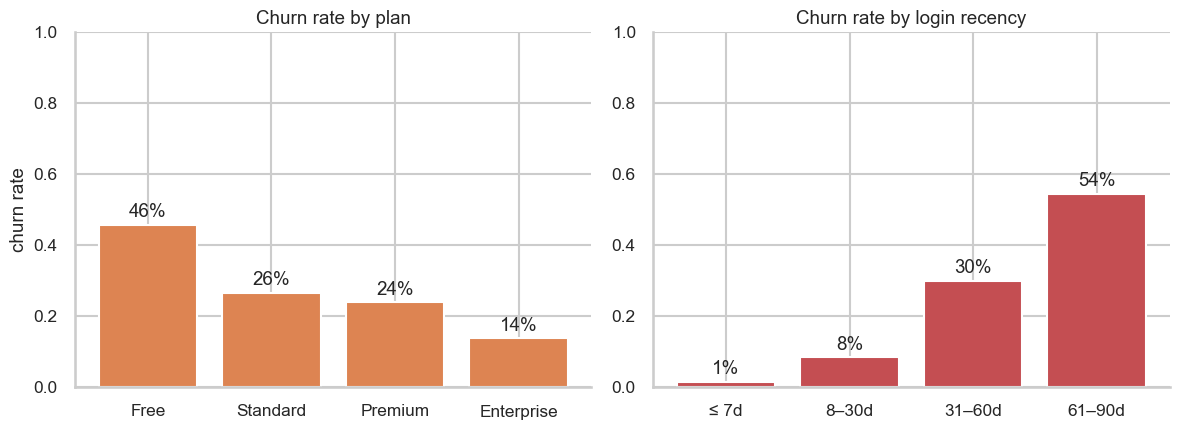

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plans = ["Free", "Standard", "Premium", "Enterprise"]
by_plan = churn_df.groupby("plan")["churned"].mean().reindex(plans)
b0 = axes[0].bar(by_plan.index, by_plan.values, color=ORANGE)
axes[0].bar_label(b0, fmt="{:.0%}".format, padding=3)
axes[0].set(title="Churn rate by plan", ylabel="churn rate")

buckets = pd.cut(churn_df["last_login_days"], bins=[-1, 7, 30, 60, 90],
                 labels=["≤ 7d", "8–30d", "31–60d", "61–90d"])
by_login = churn_df.groupby(buckets, observed=False)["churned"].mean()
b1 = axes[1].bar(by_login.index.astype(str), by_login.values, color=RED)
axes[1].bar_label(b1, fmt="{:.0%}".format, padding=3)
axes[1].set(title="Churn rate by login recency")

for ax in axes:
    ax.set_ylim(0, 1)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Observation.** Free-plan customers churn far more than Enterprise, and anyone absent for 60+ days is *very* likely to churn. Strong, clean signal — these two features will probably top the importance ranking later.

### 13.3 Train/test split — now with `stratify`

For classification we add `stratify=y` so the churn rate is **identical** in train and test. That matters whenever the target is imbalanced — without it, a small test set can drift to a misleading class mix.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

print(f"Train: {X_train.shape[0]} rows → churn {y_train.mean():.1%}")
print(f"Test : {X_test.shape[0]} rows → churn {y_test.mean():.1%}")

Train: 480 rows → churn 26.9%
Test : 120 rows → churn 26.7%


## 14. Preprocessing + comparing four classifiers

Same idea as before, but the numeric list now **includes `nps`** (a feature here, not the target).

In [30]:
numeric_cols     = ["mrr_eur", "months_active", "support_tickets", "nps", "last_login_days"]
categorical_cols = ["plan"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

### 14.1 Train and compare — with a progress bar

Four classifiers, same `Pipeline` skeleton, `tqdm` to track the loop. We score with **accuracy** for now (we'll see why that's not enough in a moment).

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import accuracy_score

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "k-NN (k=7)":          KNeighborsClassifier(n_neighbors=7),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                  n_jobs=-1),
}

clf_results = {}
for name, clf in tqdm(classifiers.items(), desc="Training classifiers"):
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    clf_results[name] = (pipe, acc)

acc_series = pd.Series({n: a for n, (_, a) in clf_results.items()}).sort_values()
best_name  = acc_series.index[-1]
best_pipe  = clf_results[best_name][0]

Training classifiers:   0%|          | 0/4 [00:00<?, ?it/s]

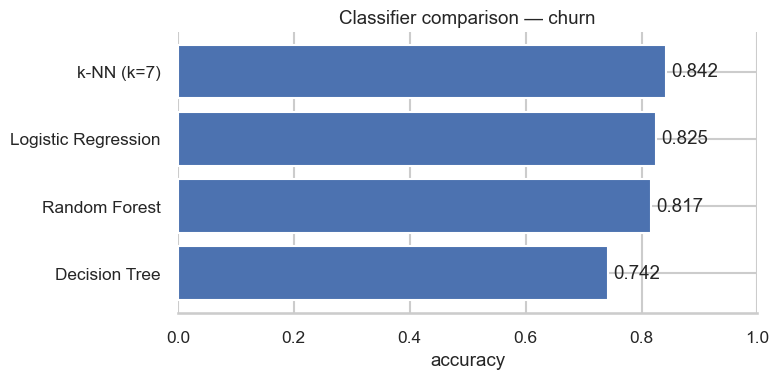

Best on this test set: k-NN (k=7)


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(acc_series.index, acc_series.values, color=BLUE)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set(xlabel="accuracy", title="Classifier comparison — churn", xlim=(0, 1))
sns.despine(left=True)
plt.tight_layout()
plt.show()

print(f"Best on this test set: {best_name}")

## 15. Decision boundaries — how each model carves up the space

A classifier's entire job is to draw a **border** between "stay" and "churn". The four models we just compared draw *very different* borders, and seeing them explains the accuracy table far better than the numbers alone.

We can only draw in 2-D, so we train each classifier on the **two strongest features** — `last_login_days` and `nps` — and colour its prediction for *every* point on the plane. Real customers sit on top; the shade behind each one is what the model would predict there.


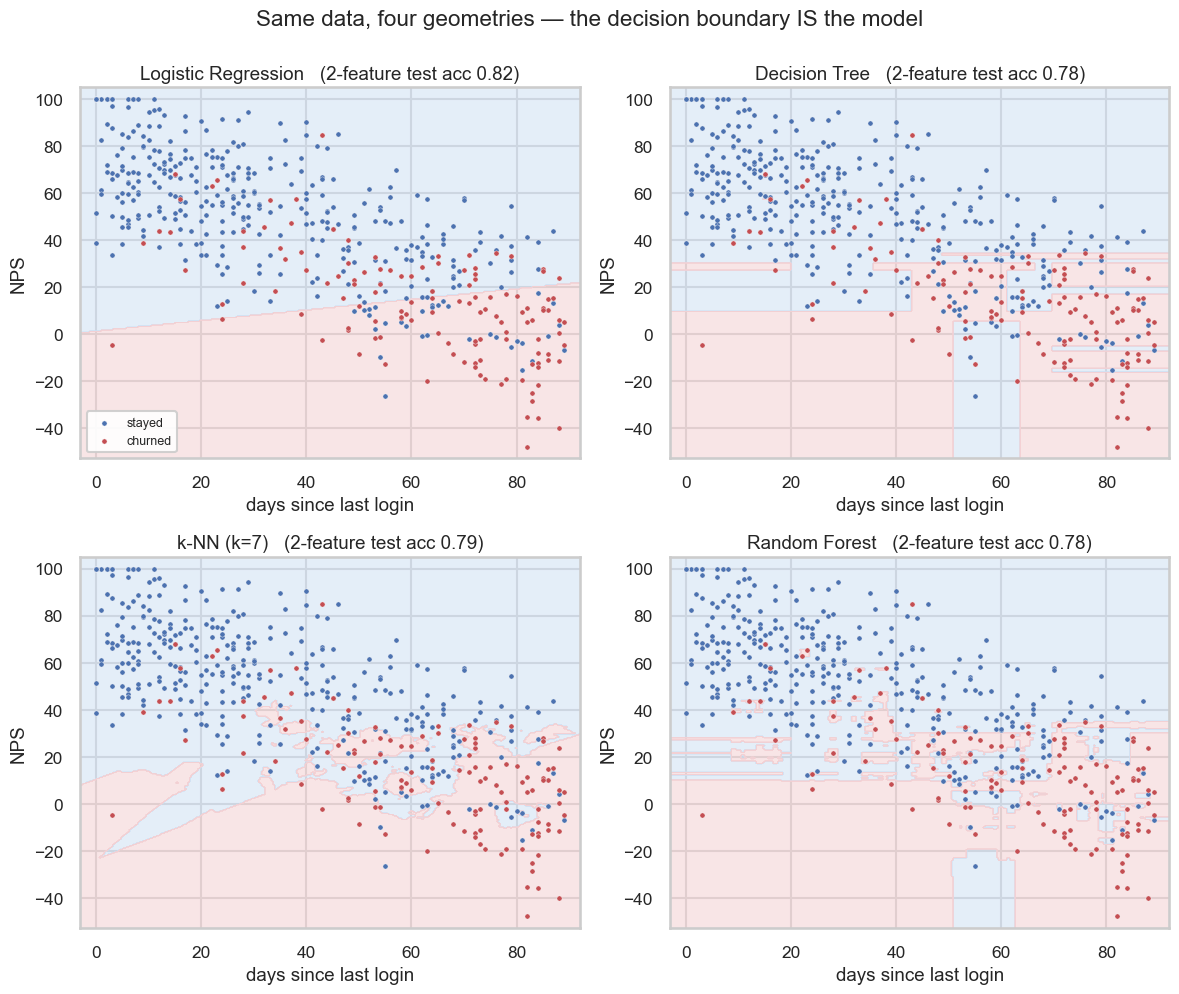

In [33]:
from matplotlib.colors import ListedColormap

two = ["last_login_days", "nps"]
Xb = X_train[two].values
yb = y_train

models2d = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "k-NN (k=7)":          KNeighborsClassifier(n_neighbors=7),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

# a fine grid covering the whole 2-D feature plane
x_min, x_max = Xb[:, 0].min() - 3, Xb[:, 0].max() + 3
y_min, y_max = Xb[:, 1].min() - 5, Xb[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
mesh = np.c_[xx.ravel(), yy.ravel()]

cmap_bg = ListedColormap(["#cfe0f3", "#f4d0d3"])   # stay / churn regions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, clf) in zip(axes.ravel(), models2d.items()):
    pipe2d = Pipeline([("sc", StandardScaler()), ("m", clf)]).fit(Xb, yb)
    zz = pipe2d.predict(mesh).reshape(xx.shape)
    acc2d = accuracy_score(y_test, pipe2d.predict(X_test[two].values))
    ax.contourf(xx, yy, zz, alpha=0.55, cmap=cmap_bg)
    ax.scatter(Xb[yb == 0, 0], Xb[yb == 0, 1], s=14, color=BLUE, edgecolor="white", lw=0.3, label="stayed")
    ax.scatter(Xb[yb == 1, 0], Xb[yb == 1, 1], s=14, color=RED,  edgecolor="white", lw=0.3, label="churned")
    ax.set(title=f"{name}   (2-feature test acc {acc2d:.2f})",
           xlabel="days since last login", ylabel="NPS")
axes[0, 0].legend(loc="lower left", fontsize=9, framealpha=0.9)
fig.suptitle("Same data, four geometries — the decision boundary IS the model", y=0.995)
plt.tight_layout()
plt.show()


**Reading the four borders.**

- **Logistic Regression** draws a single **straight line**. Fast, stable, a superb baseline — but it cannot bend, so it misclassifies anyone on the wrong side of one cut.
- **Decision Tree** draws **axis-aligned rectangles** (it splits one feature at a time). Flexible, but those blocky steps are exactly where it starts fitting noise.
- **k-NN** draws a **jagged, local** border that hugs individual points. Powerful, but sensitive to noise and to feature scale — which is why the `StandardScaler` step is non-negotiable here.
- **Random Forest** averages many trees into a **smoother staircase**. It usually strikes the best balance of flexibility and stability, which is why it tends to top the leaderboard.

> Choosing a model is, quite literally, choosing the **shape of border** you are willing to draw. The accuracy table ranks the shapes; this picture explains *why* they rank that way.


Accuracy is a useful headline but it **hides asymmetric errors**. Missing a real churner (we lose a customer) is usually costlier than a false alarm (we email a happy customer). The confusion matrix shows both kinds of mistake separately.

## 16. A closer look — the confusion matrix

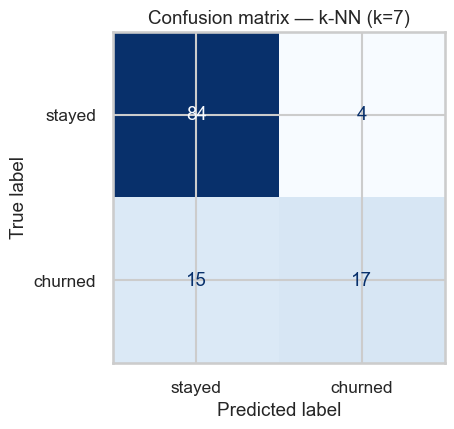

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

y_pred_best = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, display_labels=["stayed", "churned"], cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

In [35]:
print(classification_report(y_test, y_pred_best,
                            target_names=["stayed", "churned"], digits=3, zero_division=0))

              precision    recall  f1-score   support

      stayed      0.848     0.955     0.898        88
     churned      0.810     0.531     0.642        32

    accuracy                          0.842       120
   macro avg      0.829     0.743     0.770       120
weighted avg      0.838     0.842     0.830       120



**Reading the matrix.** Diagonal = correct, off-diagonal = mistakes. The report adds three per-class metrics:

- **Precision** — *"of the customers we flagged as churners, how many actually churned?"*
- **Recall** — *"of the customers who actually churned, how many did we catch?"*
- **F1-score** — harmonic mean of the two; one balanced number.

Which to optimise depends on the **business cost**:

- **High precision** when acting on a flag is expensive (sending a salesperson).
- **High recall** when *missing* a churner is expensive (you've lost the customer).

## 17. Predicting on new customers — with probabilities

### 17.1 Five hand-crafted customer profiles

In [36]:
new_customers = pd.DataFrame([
    {"mrr_eur":   199, "months_active":  3, "support_tickets": 0, "nps": -10,
     "plan": "Free",       "last_login_days": 75},   # high risk
    {"mrr_eur": 2_400, "months_active": 36, "support_tickets": 1, "nps":  65,
     "plan": "Premium",    "last_login_days":  2},   # low risk
    {"mrr_eur":   850, "months_active": 12, "support_tickets": 3, "nps":  40,
     "plan": "Standard",   "last_login_days": 20},   # medium
    {"mrr_eur": 5_900, "months_active": 48, "support_tickets": 8, "nps":   5,
     "plan": "Enterprise", "last_login_days": 45},   # complicated
    {"mrr_eur":    99, "months_active":  6, "support_tickets": 0, "nps":  80,
     "plan": "Free",       "last_login_days":  1},   # contradictory
])
new_customers

,mrr_eur,months_active,support_tickets,nps,plan,last_login_days
0,199,3,0,-10,Free,75
1,2400,36,1,65,Premium,2
2,850,12,3,40,Standard,20
3,5900,48,8,5,Enterprise,45
4,99,6,0,80,Free,1


### 17.2 Predict — label *and* probability

In [37]:
pred = best_pipe.predict(new_customers)
prob = best_pipe.predict_proba(new_customers)[:, 1]    # P(churn)

for i, (p, pr) in enumerate(zip(pred, prob)):
    bar = "█" * int(pr * 20)                            # tiny inline risk bar
    print(f"  Customer {i}: {'churn' if p else 'stay ':<5}  P(churn) = {pr:5.1%}  {bar}")

  Customer 0: churn  P(churn) = 57.1%  ███████████
  Customer 1: stay   P(churn) =  0.0%  
  Customer 2: stay   P(churn) = 14.3%  ██
  Customer 3: stay   P(churn) = 14.3%  ██
  Customer 4: stay   P(churn) =  0.0%  


**Expose the probability, not just the label.** A `0/1` decision throws away information. `P(churn) = 0.51` and `P(churn) = 0.95` are both "churn" but call for very different actions. Probabilities are how serious ML systems turn model output into business decisions.

---

### ✋ Quick exercise (~2 min) — Find the highest-risk customer

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Customer Success can only call **one** account today. Using the churn probabilities you just produced, find the index of the `new_customers` row with the **highest** `P(churn)` and print that probability.

```python
# `best_pipe` and `new_customers` already exist from the cells above.
```

In [ ]:
# ✍️ Your turn 👇
proba = best_pipe.predict_proba(new_customers)[:, 1]   # P(churn) per customer
riskiest = ...   # index of the customer with the highest churn probability


<details>
<summary>✅ <b>Solution</b></summary>

```python
proba = best_pipe.predict_proba(new_customers)[:, 1]
riskiest = int(np.argmax(proba))
print(f"Call customer {riskiest} first — P(churn) = {proba[riskiest]:.1%}")
```

`predict_proba(...)[:, 1]` gives the probability of the positive (churn) class, and `np.argmax` returns the position of the largest value — the account to prioritise.
</details>

## 18. The ROC curve — every threshold at once

`predict()` silently uses a **0.5 probability threshold**: above → "churn", below → "stay". But 0.5 is rarely the right business choice — a retention team that can call 100 customers a week wants a *strict* threshold (high precision); a team trying to catch every at-risk account wants a *loose* one (high recall).

The **ROC curve** shows what happens at *every* threshold in one picture: each point is one threshold, plotted as *false-positive rate* (happy customers wrongly flagged) vs *true-positive rate* (real churners caught). The **AUC** (area under the curve) condenses it into one number — `1.0` is a perfect ranking, `0.5` is coin-flipping.

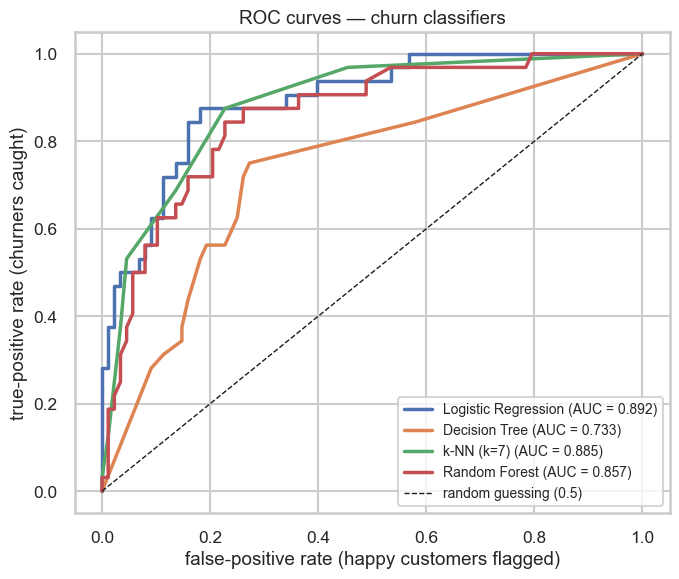

In [38]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))
for name, (pipe, _) in clf_results.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2.5, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="random guessing (0.5)")
ax.set(title="ROC curves — churn classifiers",
       xlabel="false-positive rate (happy customers flagged)",
       ylabel="true-positive rate (churners caught)")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

**Reading the curves.** The closer a curve hugs the **top-left corner**, the better the model *ranks* churners above stayers — independently of any threshold. Two practical uses:

- **Model comparison** that doesn't depend on the arbitrary 0.5 cut-off (accuracy does).
- **Threshold picking** — slide along the winning curve until the trade-off matches your business constraint, then act on `predict_proba(...) >= your_threshold` instead of `predict()`.

## 19. Choosing the threshold — turning probabilities into decisions

The ROC curve showed *every* threshold at once. Now let's **pick one**. Remember that `predict()` silently hard-codes 0.5, but the right cut-off is a **business decision**: lower it to catch more churners (higher recall, more false alarms); raise it to disturb fewer happy customers (higher precision, more misses).

This chart sweeps the threshold from 0 → 1 and plots precision and recall at each, so you can read off the cut-off that meets a target — here, *"catch at least 80% of churners."*


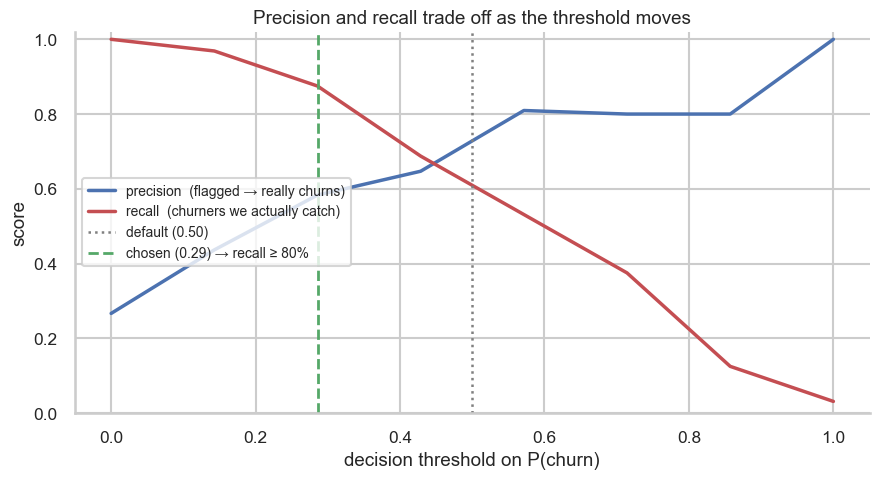

  threshold default 0.50: caught 17/32 churners (recall 53%), 4 false alarms (precision 81%)
  threshold chosen 0.29: caught 28/32 churners (recall 88%), 20 false alarms (precision 58%)


In [39]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

proba_best = best_pipe.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba_best)

# business target: recall >= 80%; pick the STRICTEST threshold that still hits it
target_recall = 0.80
ok = rec[:-1] >= target_recall
chosen = float(thr[ok][-1]) if ok.any() else 0.5

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec[:-1], color=BLUE, lw=2.5, label="precision  (flagged → really churns)")
ax.plot(thr, rec[:-1],  color=RED,  lw=2.5, label="recall  (churners we actually catch)")
ax.axvline(0.5,    color="grey",  ls=":",  lw=1.8, label="default (0.50)")
ax.axvline(chosen, color=GREEN, ls="--", lw=2,
           label=f"chosen ({chosen:.2f}) → recall ≥ {target_recall:.0%}")
ax.set(xlabel="decision threshold on P(churn)", ylabel="score", ylim=(0, 1.02),
       title="Precision and recall trade off as the threshold moves")
ax.legend(loc="center left", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

for t, lbl in [(0.5, "default 0.50"), (chosen, f"chosen {chosen:.2f}")]:
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_best >= t).astype(int)).ravel()
    print(f"  threshold {lbl}: caught {tp}/{tp + fn} churners "
          f"(recall {tp / (tp + fn):.0%}), {fp} false alarms (precision {tp / (tp + fp):.0%})")


**The lever you actually ship.** Moving the threshold retrains *nothing* — it just re-reads the same probabilities. Sliding from 0.50 to the green line trades a little precision for the recall the retention team asked for. **This** is how a model becomes a decision: choose the operating point, then act on `predict_proba(...) >= threshold` instead of the default `predict()`.


### The same model, two thresholds — side by side

The confusion matrix in §16 used the default 0.50. Here is that matrix beside the one at our **chosen** threshold, on the same test customers. Watch the bottom row: the cut-off we picked converts a chunk of *missed* churners (bottom-left) into *caught* ones (bottom-right) — the whole point of moving the lever.


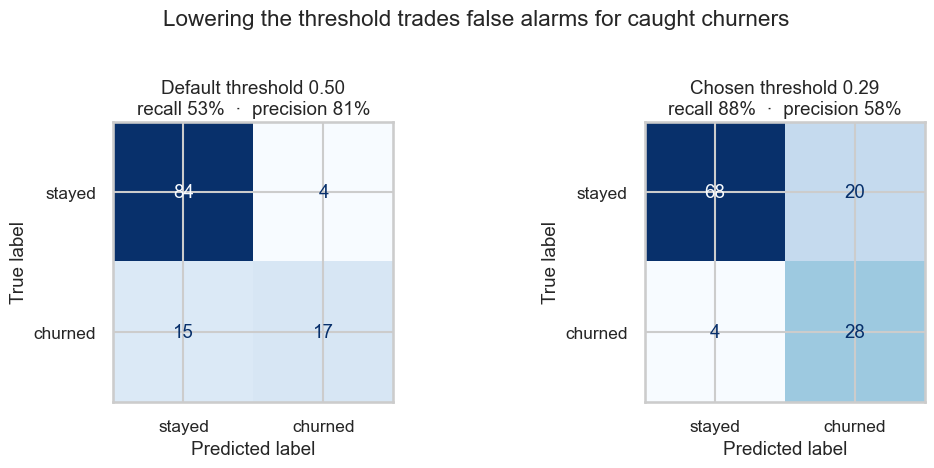

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, t, title in [(axes[0], 0.5, "Default threshold 0.50"),
                     (axes[1], chosen, f"Chosen threshold {chosen:.2f}")]:
    y_at_t = (proba_best >= t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_at_t, display_labels=["stayed", "churned"],
        cmap="Blues", ax=ax, colorbar=False)
    tn, fp, fn, tp = confusion_matrix(y_test, y_at_t).ravel()
    ax.set_title(f"{title}\nrecall {tp/(tp+fn):.0%}  ·  precision {tp/(tp+fp):.0%}")
fig.suptitle("Lowering the threshold trades false alarms for caught churners", y=1.02)
plt.tight_layout()
plt.show()


## 20. Feature importance — churn edition

Same tool as the regression side, now on the churn Random Forest. Do the top features match what the exploration in §13.2 suggested?

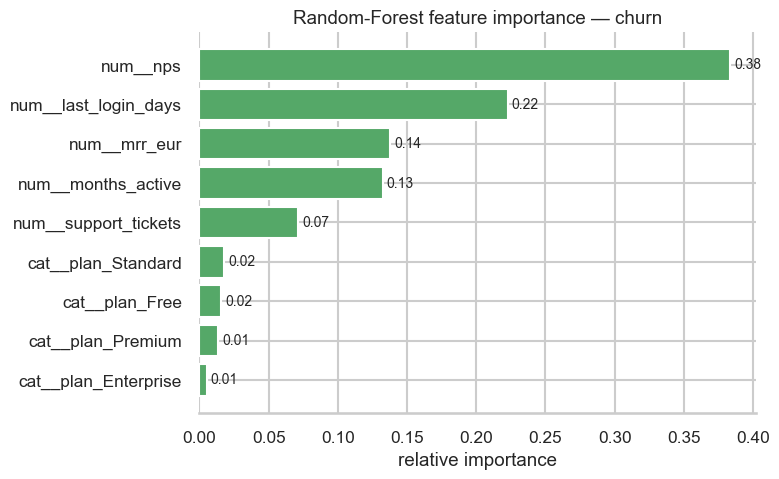

Top 5:
num__nps                0.383
num__last_login_days    0.223
num__mrr_eur            0.138
num__months_active      0.132
num__support_tickets    0.071


In [41]:
rf_pipe = clf_results["Random Forest"][0]
clf_importance = (pd.Series(rf_pipe.named_steps["model"].feature_importances_,
                            index=rf_pipe.named_steps["prep"].get_feature_names_out())
                    .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(clf_importance.index, clf_importance.values, color=GREEN)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.set(title="Random-Forest feature importance — churn", xlabel="relative importance")
sns.despine(left=True)
plt.tight_layout()
plt.show()

print("Top 5:")
print(clf_importance.tail(5)[::-1].round(3).to_string())

**Reading the chart.** Login recency, NPS, and plan rising to the top confirms the story from the exploratory bars — the model learned the same signal we saw by eye. When a model agrees with domain intuition, you trust it more; when it doesn't, you've either found something new or found a bug.

## 21. Common ML pitfalls (and how to avoid them)

| Pitfall | Symptom | Fix |
|---|---|---|
| **Data leakage** through preprocessing | suspiciously good test scores | Fit transformers inside a `Pipeline`, on train only. |
| Training and evaluating on the **same data** | 100% score that doesn't generalise | Always `train_test_split`. Prefer cross-validation. |
| Imbalanced classes | model predicts the majority class for everything | `stratify=y` in the split; report precision/recall, not just accuracy. |
| Forgetting to scale features | distance-based models (k-NN, SVM) underperform | Add `StandardScaler` to the pipeline. |
| Tuning on the test set | reported metrics overestimate real performance | Tune on cross-validation, *then* score on the test set once. |
| Reading off a single metric | nuance gets lost | Inspect a confusion matrix or a predicted-vs-actual plot. |

## 🧪 Practice exercises

### Exercise 1 — ⭐ A different classifier on churn

Train a **k-nearest-neighbours classifier with `k=11`** on the churn dataset (same train/test split). Compute accuracy, the classification report, and the confusion matrix. Don't forget the preprocessing pipeline.

In [42]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.metrics import confusion_matrix

knn_pipe = Pipeline([
    ("prep",  preprocess),
    ("model", KNeighborsClassifier(n_neighbors=11)),
])
knn_pipe.fit(X_train, y_train)

y_pred_knn = knn_pipe.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(classification_report(y_test, y_pred_knn,
                            target_names=["stayed", "churned"], zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_knn))
```

**Note.** k-NN really needs the `StandardScaler` step inside the pipeline. Without it, features on different scales (MRR in thousands, NPS on a −100..100 axis) would dominate the distance metric.
</details>

### Exercise 2 — ⭐⭐ Feedback classification (text-as-features)

Use scikit-learn's `CountVectorizer` to turn a small batch of customer feedback into numeric features, then train a `LogisticRegression` to classify each message as `"positive"`, `"neutral"`, or `"negative"`.

In [43]:
feedback_texts = [
    "Love the new dashboard! It's so much faster.",
    "The app crashed three times today, very frustrating.",
    "Could you add CSV export? Would be really helpful.",
    "My invoice doesn't match my plan, please refund.",
    "Everything works fine, no complaints.",
    "Customer support resolved my issue quickly. Thanks!",
    "Loading is really slow on mobile, bad experience.",
    "The new feature is great but a bit confusing.",
    "Refund taking forever, terrible service.",
    "Works well, no issues here.",
    "Fantastic update — keep up the good work!",
    "I'm cancelling, this is unusable.",
]
labels = [
    "positive", "negative", "neutral",
    "negative", "neutral",  "positive",
    "negative", "positive", "negative",
    "neutral",  "positive", "negative",
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.feature_extraction.text import CountVectorizer

text_pipe = Pipeline([
    ("vec",   CountVectorizer(lowercase=True, ngram_range=(1, 2))),
    ("model", LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
])

# With only 12 examples we cross-validate rather than hold out a test set
cv = cross_val_score(text_pipe, feedback_texts, labels, cv=3)
print(f"3-fold accuracy: {cv.mean():.2f} ± {cv.std():.2f}")

text_pipe.fit(feedback_texts, labels)
new = ["I hate the new pricing.", "Great product, well done!", "How do I export data?"]
for msg, pred in zip(new, text_pipe.predict(new)):
    print(f"  {pred:<8}  ←  {msg!r}")
```

**What just happened.** `CountVectorizer` turns each message into a *bag-of-words* count vector. Logistic regression learns a weight per word. With only 12 examples performance is shaky, but the *pattern* is identical to a production classifier trained on 100K examples — same Pipeline, same `.fit` / `.predict`. The LLM-based approach in the AI-workflows notebook (NB 10) is essentially a much smarter version of this.
</details>

### Exercise 3 — ⭐⭐ Regression with a feature subset

On the satisfaction-regression task, train a `LinearRegression` using **only `mrr_eur` and `last_login_days`**. Report R² and compare with the full-feature linear model (`pipe_lin`).

In [44]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
small_prep = ColumnTransformer([
    ("num", StandardScaler(), ["mrr_eur", "last_login_days"]),
])

small_pipe = Pipeline([("prep", small_prep), ("model", LinearRegression())])
small_pipe.fit(X_tr, y_tr)
r2_small = small_pipe.score(X_te, y_te)
r2_full  = pipe_lin.score(X_te, y_te)            # full-feature linear baseline

print(f"R² with 2 features  : {r2_small:.3f}")
print(f"R² with all features: {r2_full:.3f}")
print(f"Gain from extra features: {r2_full - r2_small:+.3f}")
```

A useful exercise in feature *parsimony*: most of the predictive power often comes from a handful of features. Worth knowing before you spend a week engineering 50 new ones.
</details>

### Exercise 4 — ⭐⭐ Tune `k` for k-NN

Scan `k ∈ {1, 3, 5, 7, 11, 21, 51}` on the churn dataset with 5-fold cross-validation, and plot mean accuracy vs `k`. Wrap the scan in `tqdm` for a progress bar. Which `k` is best?

In [45]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
ks = [1, 3, 5, 7, 11, 21, 51]
means, stds = [], []
for k in tqdm(ks, desc="Scanning k"):
    pipe = Pipeline([("prep", preprocess),
                     ("model", KNeighborsClassifier(n_neighbors=k))])
    s = cross_val_score(pipe, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    means.append(s.mean()); stds.append(s.std())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(ks, means, yerr=stds, marker="o", lw=2, capsize=4, color=BLUE)
ax.set_xscale("log"); ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set(xlabel="k (number of neighbours)", ylabel="Accuracy (5-fold CV)",
       title="k-NN accuracy vs k — churn dataset")
plt.tight_layout(); plt.show()

for k, m, s in zip(ks, means, stds):
    print(f"  k={k:<3} accuracy = {m:.3f} ± {s:.3f}")
```

You'll typically see a clear "sweet spot": too-small `k` overfits to noise, too-large `k` underfits and drifts toward predicting the majority class.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below is supposed to evaluate a logistic-regression classifier on the churn dataset. The reported accuracy is **suspiciously perfect**. What's wrong? Fix it.

In [46]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Buggy:
clf = LogisticRegression(max_iter=500)
clf.fit(X.select_dtypes(include="number"), y)
acc = clf.score(X.select_dtypes(include="number"), y)
print(f"Accuracy: {acc:.3f}")


Accuracy: 0.815


<details>
<summary>💡 <b>Solution</b></summary>

The model is evaluated on the **same data it was trained on** — no test split. Of course it scores high. Fix:

```python
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X.select_dtypes(include="number"), y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
clf = LogisticRegression(max_iter=500).fit(X_tr2, y_tr2)
print(f"Train accuracy: {clf.score(X_tr2, y_tr2):.3f}")
print(f"Test  accuracy: {clf.score(X_te2, y_te2):.3f}")
```

The number you report on a CV / blog post must be a *test* score. "I got 100% accuracy" on the training set is, paradoxically, evidence of a bad model — almost always overfitting.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.

### Stretch exercise C — ⭐⭐⭐ Compare three models with k-fold cross-validation

On the toy Iris dataset, compare:

- `LogisticRegression(max_iter=500)`
- `KNeighborsClassifier(n_neighbors=5)`
- `RandomForestClassifier(n_estimators=100, random_state=0)`

Use **5-fold cross-validated accuracy** with a fixed random state. Print each model's mean ± std.

In [47]:
# Your code here  👇
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

X_iris, y_iris = load_iris(return_X_y=True)

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

X_iris, y_iris = load_iris(return_X_y=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = {
    "logreg": LogisticRegression(max_iter=500),
    "knn-5":  KNeighborsClassifier(n_neighbors=5),
    "rf-100": RandomForestClassifier(n_estimators=100, random_state=0),
}

for name, model in models.items():
    scores = cross_val_score(model, X_iris, y_iris, cv=cv, scoring="accuracy")
    print(f"{name:>6}: {scores.mean():.3f} ± {scores.std():.3f}")
```

**Reasoning.** Two non-obvious habits this builds. (1) **`StratifiedKFold` with `shuffle=True, random_state=...`** is the right default for classification — it keeps class proportions stable across folds, and the random state makes the result reproducible. (2) Report the **standard deviation** alongside the mean. If model A is `0.95 ± 0.04` and model B is `0.96 ± 0.02`, B is the safer choice — not because the mean is higher (it's barely higher) but because it's more consistent.
</details>

### Stretch exercise D — ⭐⭐⭐ Build a clean Pipeline

Build a sklearn `Pipeline` that:

1. Scales features with `StandardScaler`.
2. Trains a `LogisticRegression(max_iter=1000)`.

Fit on the Wine dataset, then print the **5-fold CV accuracy** and the **coefficient of each scaled feature**, sorted by absolute size.

Why a Pipeline rather than fit-the-scaler-then-fit-the-model separately? Because the scaler must see only the training fold in each CV split — see your reasoning below.

In [48]:
# Your code here  👇
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

X_wine, y_wine = load_wine(return_X_y=True)
wine_features = load_wine().feature_names

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

X_wine, y_wine = load_wine(return_X_y=True)
wine_features = load_wine().feature_names

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000)),
])

scores = cross_val_score(pipe, X_wine, y_wine, cv=5, scoring="accuracy")
print(f"CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

pipe.fit(X_wine, y_wine)
coefs = pipe.named_steps["clf"].coef_           # (n_classes, n_features)
magnitude = np.abs(coefs).mean(axis=0)          # average abs across classes
for i in np.argsort(magnitude)[::-1]:
    print(f"  {wine_features[i]:<25}  {magnitude[i]:.3f}")
```

**Reasoning.** **Always** use a Pipeline when preprocessing depends on the data — and StandardScaler very much does (it estimates a mean and a std). If you scale once on the whole dataset and *then* run CV, you've leaked information from the test fold into the training fold via the scaler's parameters. A Pipeline re-fits the scaler inside each fold, which is the honest evaluation. The same principle applies to OneHotEncoder, PCA, SelectKBest — anything with `.fit`.
</details>

## 🧠 Key takeaways

1. Every scikit-learn estimator follows the same **`fit / predict / score`** contract — `fit` learns-and-remembers, `predict` applies. Interchangeable building blocks, and the reason churn reused satisfaction's entire workflow with barely a line changed.
2. **Always** split into train/test (and prefer cross-validation). Never train on your test set.
3. Use a **`Pipeline`** to bundle preprocessing with the model — this is how you avoid data leakage.
4. Watch the **bias–variance trade-off**: as complexity rises, training score keeps climbing but test score peaks then falls. The gap between the two curves *is* overfitting.
5. Pick metrics that match the problem: **MAE/RMSE/R²** for regression, **accuracy/precision/recall/F1** for classification. Read a **predicted-vs-actual** plot or a **confusion matrix** before declaring victory.
6. **Cross-validation** gives an honest score *with an error bar* (mean ± std); **`GridSearchCV`** automates "is X better than Y?" — tune on CV, score on the test set once.
7. A classifier's **decision boundary** is the model — linear, boxy, jagged, or smooth. Choosing a model chooses a shape.
8. For classification, **probabilities (`predict_proba`)** and the **ROC curve** carry far more than a 0/1 label — and the **0.5 threshold is a default, not a law**: sweep precision/recall and pick the operating point your costs imply.
9. **Feature importance** is a free interpretability tool — and a quiet leakage detector. Prefer **permutation importance** (held-out, model-agnostic) over impurity-based importance, which is biased toward high-cardinality/continuous features.
10. Two diagnostics tell you which lever to pull: the **complexity curve** (§9 — train vs test as the model grows) and the **learning curve** (does more *data* still help?).


## ✅ Self-assessment

- [ ] Split a dataset with `train_test_split` (and `stratify` for classification)
- [ ] Build a `Pipeline(ColumnTransformer, model)` for mixed numeric + categorical features
- [ ] Visualise the line a linear model learned (slope + intercept)
- [ ] Train a regressor and read MAE, RMSE, R²
- [ ] Diagnose overfitting from a train-vs-test complexity curve
- [ ] Read a learning curve and judge whether more data would help
- [ ] Plot a predicted-vs-actual diagnostic
- [ ] Run cross-validation and report mean ± std
- [ ] Tune a hyperparameter with `GridSearchCV`
- [ ] Train and compare 3+ classifiers
- [ ] Read and compare classifier decision boundaries
- [ ] Interpret a confusion matrix and the precision / recall / F1 trio
- [ ] Read an ROC curve and explain what AUC measures
- [ ] Pick a decision threshold from a precision/recall sweep
- [ ] Read feature importances (impurity vs permutation) and use them to spot data leakage

## 🚀 Next step

Continue with **Notebook 9 (fast track) — APIs & SQL: Getting Real Data In**, where you stop being handed data and start fetching it yourself — over HTTP from web APIs and out of relational databases with SQL.